In [160]:
#binomial classes

In [161]:
import math

In [162]:
#binary search tree (required in the binomial pricing function)

class TreeNode:
    def __init__(self,value):
        self.value = value
        self.left = None
        self.right = None
    
class BinarySearchTree:
    def __init__(self):
        self.root = None

    def insert(self,value):
        if self.root is None:
            self.root = TreeNode(value)
        else:
            self._insert_recursive(self.root,value)
        
    def _insert_recursive(self,node,value):
        if value < node.value:
            if node.left is None:
                node.left = TreeNode(value)
            else:
                self._insert_recursive(node.left,value)
        elif value > node.value:
            if node.right is None:
                node.right = TreeNode(value)
            else:
                self._insert_recursive(node.right, value)

    #print function
    def in_order(self):
        result = []
        self._in_order_recursive(self.root, result)
        return result

    def _in_order_recursive(self, node, result):
        if node is not None:
            self._in_order_recursive(node.left, result)
            result.append(node.value)
            self._in_order_recursive(node.right, result)

In [163]:
#Binomial Pricing Model

#S = asset price
#K = strike price
#T = expiration time (yrs)
#r = risk free rate (annualized)
#sig = volatility
#N = time steps in model

class Binomial:
    def __init__(self,S,K,T,r,sig,N):
        self.S = S
        self.K = K
        self.T = T
        self.r = r
        self.sig = sig
        self.N = N

        #derived factors
        # deltaT is the time step size for each period.
        # up represents the upward movement factor for the asset price.
        # down represents the downward movement factor for the asset price.
        # riskNeutral is the risk-neutral probability of an upward price movement.
        self.deltaT = self.T/self.N
        self.up = math.exp(self.sig*math.sqrt(self.deltaT))
        self.down = 1 / self.up
        self.riskNeutral = (math.exp(self.r*self.deltaT) - self.down)/(self.up - self.down)

        #bst initialization
        self.bst = BinarySearchTree()
    
    def PricingTree(self):
        self.bst.insert(self.S)
        for i in range(1, self.N + 1):
            for j in range(i+1):
                price = (self.S * self.up ** j) * (self.down ** (i-j))
                self.bst.insert(price)

    def getTree(self):
        return self.bst.in_order()


In [164]:
testS = 100
testK = 110
testT = 5
testr = .05
testsig = .1
testN = 15

biTest = Binomial(testS,testK,testT,testr,testsig,testN)

#trying to test print function, adn for wahtever reason the tree isnt filling wiht value s....

In [165]:
biTest.PricingTree()
print(biTest.getTree())

[42.062002605411536, 44.561925635326304, 47.21042968298592, 50.016345547806964, 52.98902888103111, 52.98902888103112, 56.138391379892866, 56.13839137989287, 59.474933835788846, 59.47493383578885, 63.009781146639824, 63.00978114663984, 66.75471941018574, 66.75471941018576, 66.75471941018577, 70.72223522189253, 74.92555730849979, 74.9255573084998, 79.37870063602692, 79.37870063602693, 79.37870063602695, 84.09651313930473, 89.09472522884109, 89.0947252288411, 94.39000224008953, 94.39000224008954, 94.39000224008956, 100, 100.00000000000001, 105.94342369612505, 105.94342369612507, 105.94342369612508, 112.24009024456672, 112.24009024456673, 112.24009024456674, 118.91099436471445, 118.91099436471447, 118.91099436471448, 125.97837858108483, 125.97837858108484, 125.97837858108485, 133.46580738566718, 141.39824580805154, 141.39824580805157, 149.80214265531242, 149.80214265531245, 158.70551869919134, 158.70551869919137, 168.13806010461727, 168.1380601046173, 178.1312174110801, 178.13121741108012,

In [166]:
arr1 = biTest.getTree()
arr1[0]

42.062002605411536

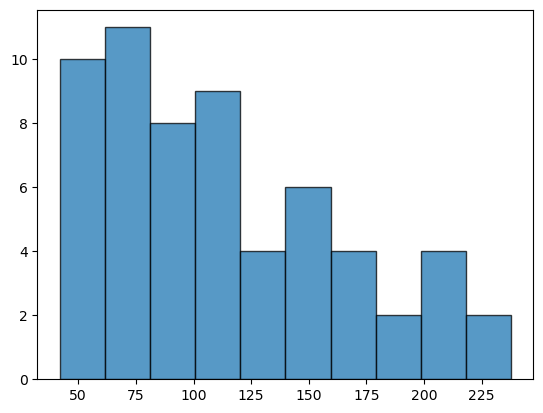

In [167]:
import matplotlib.pyplot as plt

plt.hist(arr1, bins=10, edgecolor="black", alpha=0.75)
plt.show()